In [1]:
import pandas as pd

df = pd.read_csv("C:\\Users\\ayush\\Downloads\\CA2.csv")

df = df.dropna()
df = df[(df['Production'] > 0) & (df['Area'] > 0)]

df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


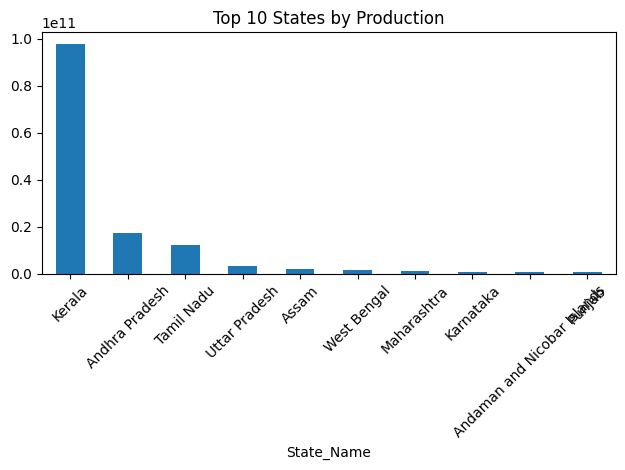

In [2]:
import matplotlib.pyplot as plt

df.groupby('State_Name')['Production'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

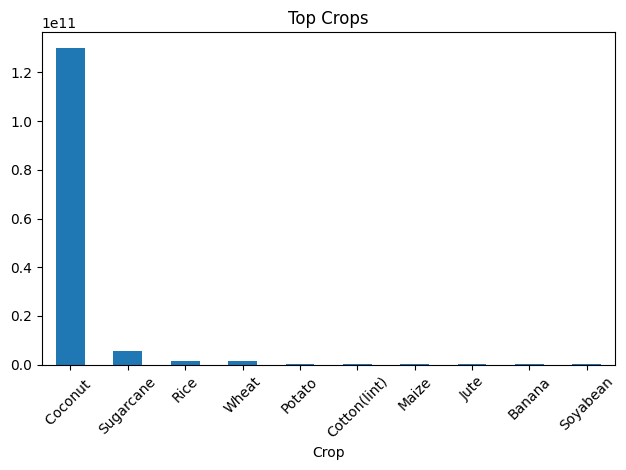

In [3]:
df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Crops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

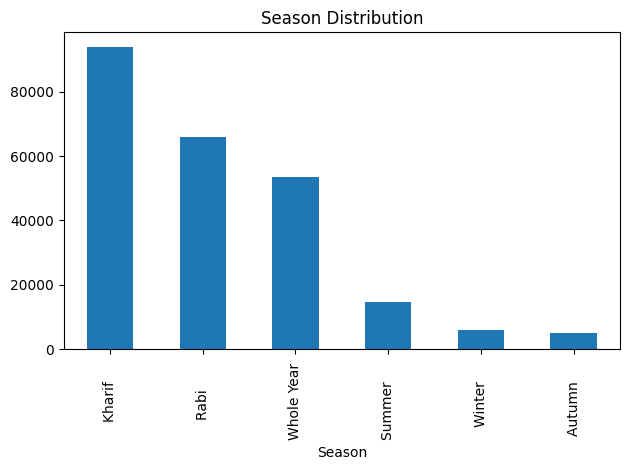

In [4]:
df['Season'].value_counts().plot(kind='bar')
plt.title("Season Distribution")
plt.tight_layout()
plt.show()

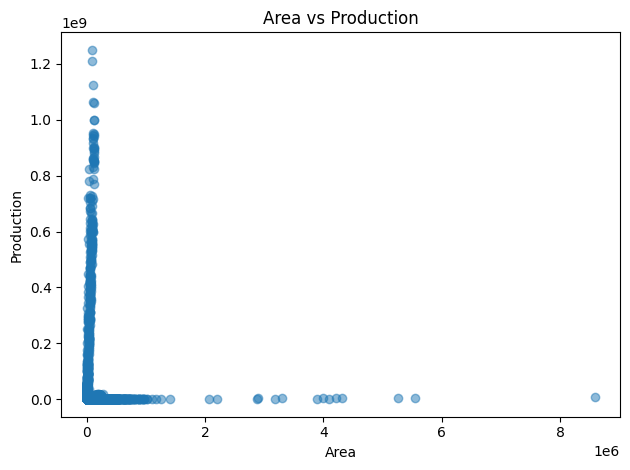

In [5]:
plt.scatter(df['Area'], df['Production'], alpha=0.5)
plt.xlabel("Area")
plt.ylabel("Production")
plt.title("Area vs Production")
plt.tight_layout()
plt.show()

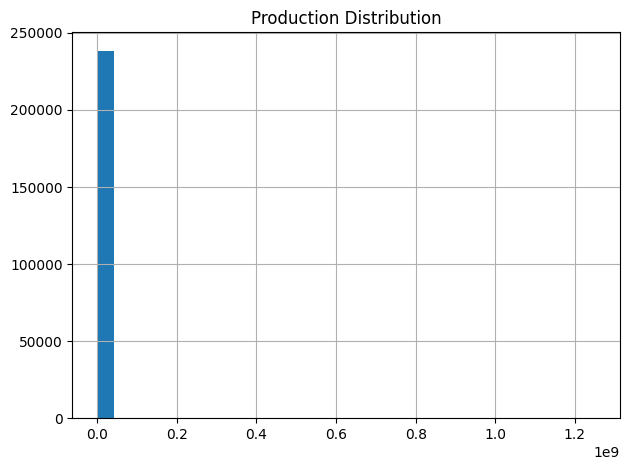

In [6]:
df['Production'].hist(bins=30)
plt.title("Production Distribution")
plt.tight_layout()
plt.show()

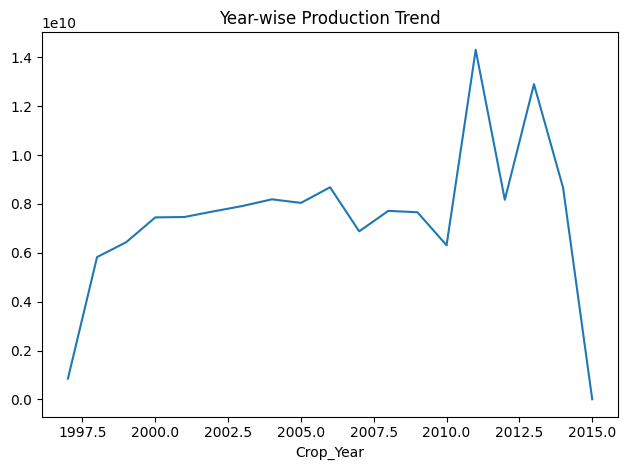

In [7]:
df.groupby('Crop_Year')['Production'].sum().plot()
plt.title("Year-wise Production Trend")
plt.tight_layout()
plt.show()

Model Performance:

MAE: 109364.52194164599
MSE: 11201636739233.7
R2 Score: 0.97035812592449


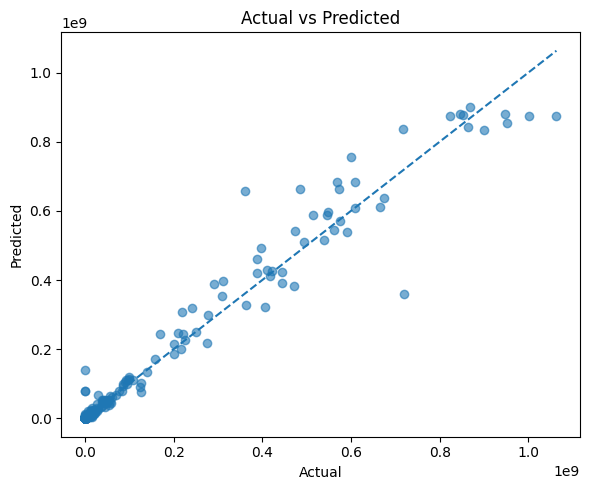

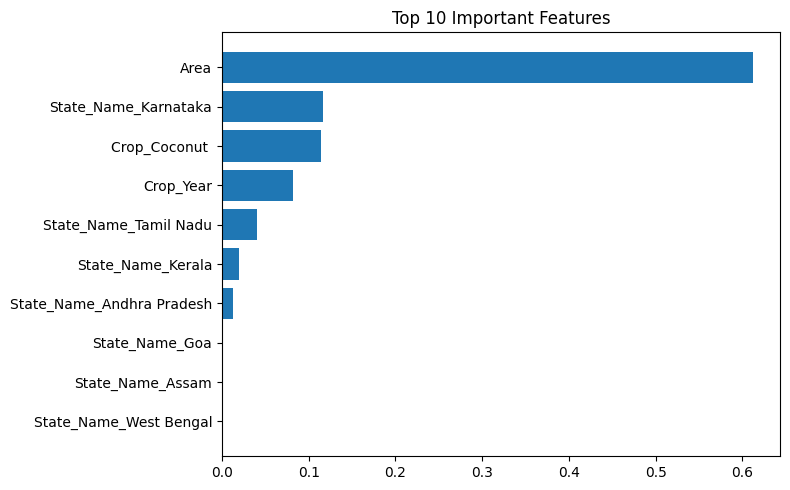

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load fresh data (independent execution)
df = pd.read_csv("C:\\Users\\ayush\\Downloads\\CA2.csv")

# Cleaning
df = df.dropna()
df = df[(df['Production'] > 0) & (df['Area'] > 0)]

# Drop unnecessary column safely
if 'District_Name' in df.columns:
    df = df.drop('District_Name', axis=1)

# Feature Engineering
df_model = pd.get_dummies(df, columns=['State_Name', 'Season', 'Crop'], drop_first=True)

# Ensure all columns are numeric
df_model = df_model.apply(pd.to_numeric)

# Split features/target
X = df_model.drop('Production', axis=1)
y = df_model['Production']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Model Performance:\n")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Graph 7: Actual vs Predicted

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()


# Graph 8: Feature Importance

importances = model.feature_importances_
features = X.columns

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()